# 전처리 변경 후 실제 성능 비교

실제 라벨 255,001행, 10조건 × 3시드(42/1/7), 각 5-fold pooled OOF.
이 노트북은 실행이 완료된 실험 CSV만 읽는다. 전처리 규칙의 타당성과 성능 향상은 별개다.
**3시드 표준편차는 새 데이터에 대한 신뢰구간이 아니다.**

clean=세 변경 묶음, impute=대치만, ratio=시간차 비율·관련 플래그만,
missing=시각 결측 표현·원래 결측 플래그만. 이전 붕괴 프로토콜 점수는 비교하지 않는다.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
ROOT=next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'src/features.py').exists())
OUT=ROOT/'output'
runs=pd.read_csv(OUT/'preprocessing_full_runs.csv')
summary=pd.read_csv(OUT/'preprocessing_full_summary.csv')
paired=pd.read_csv(OUT/'preprocessing_full_paired_deltas.csv')
assert len(runs)==30 and runs.groupby('phase_key').size().eq(3).all()
assert not runs.duplicated(['phase_key','seed']).any()
plt.rcParams['font.family']='Malgun Gothic'
plt.rcParams['axes.unicode_minus']=False
display(summary.round(6))

,phase_key,macro_f1_nested_mean,macro_f1_nested_std,log_loss_mean,log_loss_std,roc_auc_mean,roc_auc_std
0,P4,0.574916,0.000964,0.448016,0.000267,0.641194,0.001266
1,P4_clean,0.574541,0.000726,0.448216,0.000133,0.640596,0.000628
2,P4_impute,0.574335,0.000803,0.448136,0.000255,0.640820,0.001145
3,P4_missing,0.574258,0.001742,0.448055,0.000433,0.641177,0.001735
4,P4_ratio,0.574299,0.000271,0.448158,0.000148,0.640756,0.000703
5,P6_clean,0.575685,0.001075,0.447577,0.000305,0.642804,0.001326
6,P6_fixed,0.576062,0.001491,0.447597,0.000420,0.642757,0.001522
7,P6_fixed_impute,0.575888,0.001210,0.447680,0.000361,0.642486,0.001311
8,P6_fixed_missing,0.575551,0.000788,0.447566,0.000367,0.642765,0.001484
9,P6_fixed_ratio,0.575058,0.001278,0.447664,0.000112,0.642411,0.000307


## 같은 시드에서의 변경 효과
점은 변경 조건−기준 조건의 3시드 평균, 막대는 짝지은 차이의 표본 표준편차(±1 SD)다.
F1/AUC는 오른쪽, LogLoss는 왼쪽이 좋다. 0.002는 실무 참고선이며 통계적 유의수준이 아니다.


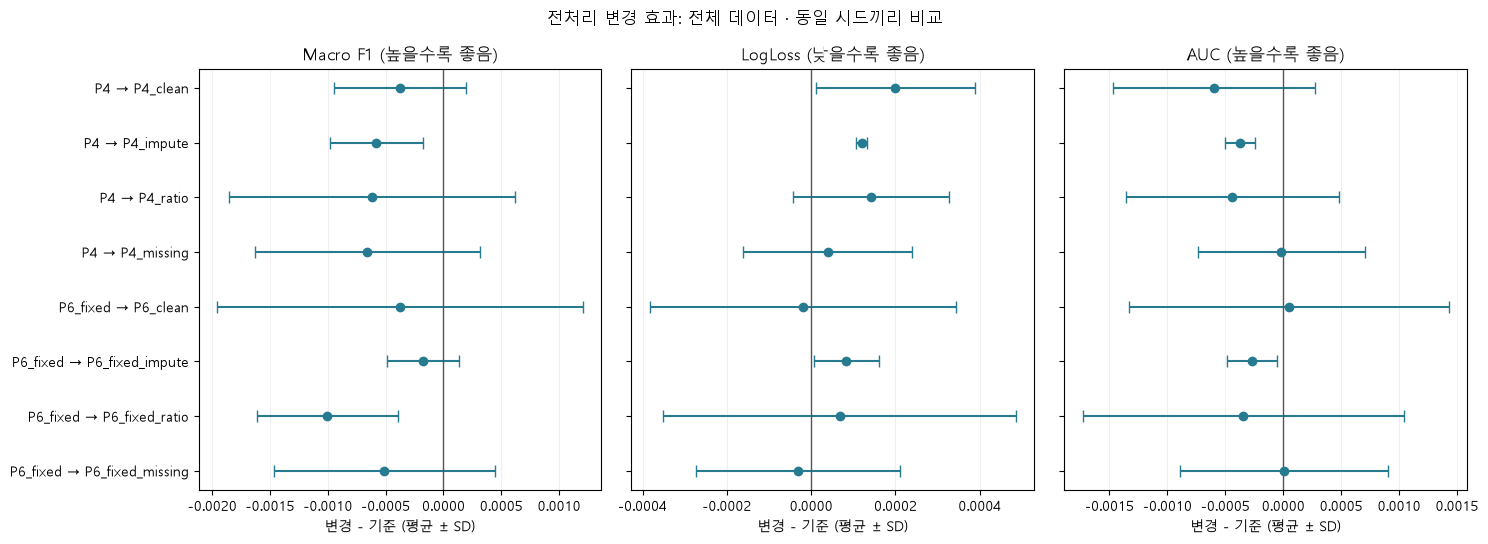

,reference,variant,macro_f1_nested_delta_mean,macro_f1_nested_delta_std,log_loss_delta_mean,log_loss_delta_std,roc_auc_delta_mean,roc_auc_delta_std
0,P4,P4_clean,-0.000375,0.000573,0.000200,0.000189,-0.000598,0.000876
1,P4,P4_impute,-0.000580,0.000403,0.000120,0.000013,-0.000374,0.000126
2,P4,P4_ratio,-0.000617,0.001235,0.000142,0.000185,-0.000439,0.000917
3,P4,P4_missing,-0.000657,0.000969,0.000039,0.000200,-0.000018,0.000722
4,P6_fixed,P6_clean,-0.000377,0.001584,-0.000020,0.000363,0.000047,0.001382
5,P6_fixed,P6_fixed_impute,-0.000174,0.000311,0.000084,0.000078,-0.000271,0.000216
6,P6_fixed,P6_fixed_ratio,-0.001003,0.000610,0.000068,0.000418,-0.000347,0.001386
7,P6_fixed,P6_fixed_missing,-0.000510,0.000957,-0.000030,0.000242,0.000007,0.000898


In [2]:
metrics=[('macro_f1_nested','Macro F1 (높을수록 좋음)'),('log_loss','LogLoss (낮을수록 좋음)'),('roc_auc','AUC (높을수록 좋음)')]
fig, axes=plt.subplots(1,3,figsize=(15,5.5),sharey=True)
labels=(paired.reference+' → '+paired.variant).tolist()
for ax,(metric,title) in zip(axes,metrics):
    x=paired[metric+'_delta_mean']; e=paired[metric+'_delta_std']
    ax.errorbar(x,range(len(labels)),xerr=e,fmt='o',capsize=4,color='#267b91')
    ax.axvline(0,color='#555555',lw=1)
    ax.set_title(title); ax.set_xlabel('변경 - 기준 (평균 ± SD)')
    ax.grid(axis='x',alpha=.2)
axes[0].set_yticks(range(len(labels)),labels); axes[0].invert_yaxis()
fig.suptitle('전처리 변경 효과: 전체 데이터 · 동일 시드끼리 비교')
fig.tight_layout(); fig.savefig(OUT/'preprocessing_full_effects.png',dpi=160); plt.show()
display(paired.drop(columns=[c for c in paired if c.endswith('_deltas')]).round(6))

## 시드별 Macro F1
조건별 색 선은 모델 복잡도 곡선이 아니라 시드 반복 결과다. 가로축 시드는 시간 순서가 아니다.


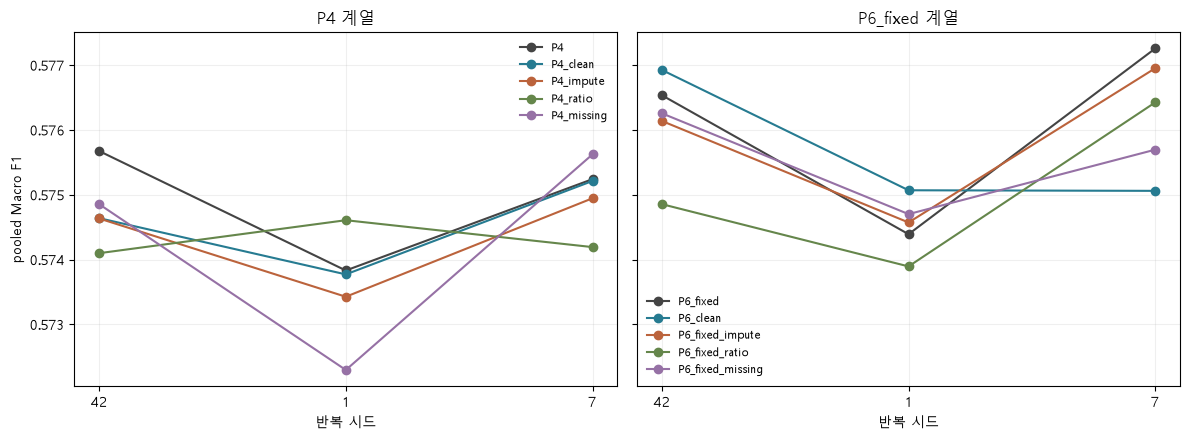

In [3]:
groups=[['P4','P4_clean','P4_impute','P4_ratio','P4_missing'],['P6_fixed','P6_clean','P6_fixed_impute','P6_fixed_ratio','P6_fixed_missing']]
fig,axes=plt.subplots(1,2,figsize=(12,4.5),sharey=True)
colors=['#444444','#267b91','#bb633c','#65864b','#9671a5']
for ax,keys in zip(axes,groups):
    for key,color in zip(keys,colors):
        r=runs[runs.phase_key.eq(key)].set_index('seed').reindex([42,1,7])
        ax.plot(range(3),r.macro_f1_nested,marker='o',label=key,color=color)
    ax.set_xticks(range(3),['42','1','7']); ax.set_xlabel('반복 시드'); ax.set_title(keys[0]+' 계열')
    ax.grid(alpha=.2); ax.legend(frameon=False,fontsize=8)
axes[0].set_ylabel('pooled Macro F1'); fig.tight_layout()
fig.savefig(OUT/'preprocessing_full_seed_variation.png',dpi=160); plt.show()

## 개별 결과와 선택 기록
트리 수와 임계값은 outer-valid 라벨을 보지 않고 내부 holdout에서 선택했다.


In [4]:
display(runs)
display(pd.read_csv(OUT/'preprocessing_full_selection_checks.csv'))

,phase_key,seed,macro_f1_nested,log_loss,roc_auc,selected_n_estimators,per_fold_thresholds,elapsed_sec
0,P4,42,0.575675,0.447748,0.642545,"[50, 50, 50, 50, 50]","[0.22, 0.22, 0.23, 0.22, 0.22]",55.5
1,P6_fixed,42,0.576536,0.447334,0.643916,"[50, 50, 50, 50, 50]","[0.22, 0.23, 0.22, 0.23, 0.23]",63.6
2,P4_clean,42,0.574639,0.448166,0.640939,"[75, 75, 75, 75, 50]","[0.23, 0.22, 0.22, 0.22, 0.22]",69.7
3,P6_clean,42,0.576926,0.447225,0.644317,"[50, 50, 50, 50, 50]","[0.22, 0.23, 0.23, 0.23, 0.23]",66.1
4,P4_impute,42,0.574634,0.447879,0.642026,"[50, 50, 50, 50, 50]","[0.23, 0.22, 0.22, 0.22, 0.22]",68.7
5,P4_ratio,42,0.574098,0.447991,0.641504,"[75, 50, 50, 75, 75]","[0.23, 0.22, 0.23, 0.24, 0.23]",67.5
6,P4_missing,42,0.574855,0.447725,0.642624,"[50, 50, 50, 50, 50]","[0.22, 0.23, 0.22, 0.22, 0.22]",66.3
7,P6_fixed_impute,42,0.576139,0.447502,0.643445,"[50, 50, 50, 50, 50]","[0.22, 0.23, 0.22, 0.23, 0.22]",65.3
8,P6_fixed_ratio,42,0.574855,0.447761,0.642306,"[75, 50, 75, 50, 75]","[0.23, 0.23, 0.24, 0.22, 0.23]",68.8
9,P6_fixed_missing,42,0.576257,0.447174,0.644427,"[50, 50, 50, 50, 50]","[0.23, 0.23, 0.23, 0.23, 0.22]",66.5


,phase,seed,thresholds,trees,threshold_at_boundary
0,P4,42,"[0.22, 0.22, 0.23, 0.22, 0.22]","[50, 50, 50, 50, 50]",False
1,P6_fixed,42,"[0.22, 0.23, 0.22, 0.23, 0.23]","[50, 50, 50, 50, 50]",False
2,P4_clean,42,"[0.23, 0.22, 0.22, 0.22, 0.22]","[75, 75, 75, 75, 50]",False
3,P6_clean,42,"[0.22, 0.23, 0.23, 0.23, 0.23]","[50, 50, 50, 50, 50]",False
4,P4_impute,42,"[0.23, 0.22, 0.22, 0.22, 0.22]","[50, 50, 50, 50, 50]",False
5,P4_ratio,42,"[0.23, 0.22, 0.23, 0.24, 0.23]","[75, 50, 50, 75, 75]",False
6,P4_missing,42,"[0.22, 0.23, 0.22, 0.22, 0.22]","[50, 50, 50, 50, 50]",False
7,P6_fixed_impute,42,"[0.22, 0.23, 0.22, 0.23, 0.22]","[50, 50, 50, 50, 50]",False
8,P6_fixed_ratio,42,"[0.23, 0.23, 0.24, 0.22, 0.23]","[75, 50, 75, 50, 75]",False
9,P6_fixed_missing,42,"[0.23, 0.23, 0.23, 0.23, 0.22]","[50, 50, 50, 50, 50]",False


## 해석 범위
분할 시드를 반복해도 동일 데이터셋이다. 작은 차이의 통계적 유의성이나 배포 성능을 확정하지 않는다.
모든 조건의 학습 크기·nested TE·그리드·임계값 선택 절차는 같다.
전체 원본을 사용하는 비타깃 집계 계약은 유지했으므로 시간순 배포 검증은 별도다.
종합 판정은 `output/preprocessing_full_evaluation.md`, 원본 실행 로그/그리드 점수는
`output/baseline_recovery_v2_preprocessing_full_seed*.{csv,md,log}`에 있다.
